# Notebook Header & Import

In [1]:
# EEEM068: Industrial Waste Classification
# Evaluation Notebook (Jupyter version of test.py)

# Standard library imports
import os
import json
import argparse
import time

# Metrics and utilities
from sklearn import metrics
import yaml
import numpy as np
import torch
import torch.nn as nn

# Data loading and transforms
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Evaluation metrics
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Project utilities
from utils.data import get_transforms, load_class_mapping
from utils.models import get_model
from utils.plotting import save_confusion_matrix


# Evaluation Function

In [2]:
@torch.no_grad()
def evaluate(model, loader, device, n_classes):
    # Run model in evaluation mode and measure inference latency
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    # Warmup pass to avoid first‑batch latency spikes
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    _ = model(dummy_input)

    # Start timing (sync ensures accurate GPU timing)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    start_time = time.time()

    for images, labels in loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

    # End timing (sync ensures all GPU work is complete)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    total_time = time.time() - start_time

    # Latency in ms per image
    latency = (total_time / len(loader.dataset)) * 1000

    print("-" * 30)
    print("  INFERENCE PERFORMANCE")
    print("-" * 30)
    print(f"  Total Images: {len(loader.dataset)}")
    print(f"  Total Time:   {total_time:.2f}s")
    print(f"  Latency:      {latency:.2f} ms/image")
    print("-" * 30)

    return (
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs)
    )


# Metric Function


In [3]:
# Compute accuracy, F1, precision, recall, AUC, mAP, and per‑class metrics
def compute_metrics(labels, preds, probs, n_classes, class_names=None):
    # Core classification metrics
    metrics_dict = {
        "accuracy": float(np.mean(labels == preds)),
        "f1_macro": float(f1_score(labels, preds, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(labels, preds, average="weighted", zero_division=0)),
        "precision_macro": float(precision_score(labels, preds, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(labels, preds, average="macro", zero_division=0)),
    }

    # AUC (one‑vs‑rest)
    try:
        one_hot = np.eye(n_classes)[labels]
        metrics_dict["auc"] = float(
            roc_auc_score(one_hot, probs, average="macro", multi_class="ovr")
        )
    except Exception as e:
        metrics_dict["auc"] = None
        print(f"[Warning] AUC could not be computed: {e}")

    # Mean Average Precision (mAP)
    try:
        one_hot = np.eye(n_classes)[labels]
        metrics_dict["mAP"] = float(
            average_precision_score(one_hot, probs, average="macro")
        )
    except Exception as e:
        metrics_dict["mAP"] = None
        print(f"[Warning] mAP could not be computed: {e}")

    # Per‑class precision/recall/F1
    metrics_dict["per_class_report"] = classification_report(
        labels,
        preds,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    return metrics_dict


#  Save Metrics Function


In [4]:
# Save test metrics to disk and print a summary
def save_test_metrics(metrics, output_dir):
    path = os.path.join(output_dir, "test_metrics.json")

    with open(path, "w") as f:
        json.dump(metrics, f, indent=2)

    print(f"[Metrics] Test results saved to {path}\n")

    # Print a simple summary (exclude per-class breakdown)
    print("=" * 40)
    print("  TEST RESULTS")
    print("=" * 40)
    for k, v in metrics.items():
        if k == "per_class_report":
            continue
        print(f"{k:<20} {v}")
    print("=" * 40)


# Visualizations

In [5]:
# Plot per‑class F1 scores as a horizontal bar chart
def plot_per_class_f1(metrics, class_names, output_dir):
    # Extract per‑class F1 values
    f1_scores = [metrics["per_class_report"][cls]["f1-score"] for cls in class_names]

    # Sort classes by F1 for easier interpretation
    sorted_data = sorted(zip(class_names, f1_scores), key=lambda x: x[1], reverse=True)
    sorted_classes, sorted_f1 = zip(*sorted_data)

    plt.figure(figsize=(12, 10))
    sns.set_style("whitegrid")

    # Horizontal bar plot
    sns.barplot(
        x=list(sorted_f1),
        y=list(sorted_classes),
        hue=list(sorted_classes),
        palette="viridis",
        legend=False
    )

    # Macro‑average reference line
    mean_f1 = metrics["f1_macro"]
    plt.axvline(x=mean_f1, color='red', linestyle='--', label=f'Macro Avg F1: {mean_f1:.2f}')

    plt.title("Per-Class F1-Score (Test Set)", fontsize=16)
    plt.xlabel("F1-Score", fontsize=12)
    plt.ylabel("Waste Category", fontsize=12)
    plt.xlim(0, 1.0)
    plt.legend(loc='lower right')

    plt.tight_layout()

    # Save figure
    plot_path = os.path.join(output_dir, "per_class_f1_bar.png")
    plt.savefig(plot_path, dpi=300)
    print(f"[Visuals] Per-class F1 plot saved to {plot_path}")

    plt.show()


In [6]:
# Visualize the most confident misclassifications made by the model
def plot_misclassified(model, loader, device, class_names, n_images=5, output_dir=None):
    model.eval()
    errors = []

    # Collect misclassified samples
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            probs = torch.softmax(outputs, dim=1)
            conf, preds = torch.max(probs, 1)

            for i in range(len(preds)):
                if preds[i] != labels[i]:
                    errors.append({
                        "img": images[i],  # original (normalized) tensor
                        "pred": class_names[preds[i]],
                        "label": class_names[labels[i]],
                        "conf": conf[i].item()
                    })

    # Keep the highest‑confidence mistakes
    errors = sorted(errors, key=lambda x: x["conf"], reverse=True)[:n_images]

    # Plot results
    fig, axes = plt.subplots(1, n_images, figsize=(20, 5))
    if n_images == 1:
        axes = [axes]

    for i, error in enumerate(errors):
        # Unnormalize image for display
        img = error["img"].permute(1, 2, 0).numpy()
        img = np.clip(
            img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]),
            0, 1
        )

        axes[i].imshow(img)
        axes[i].set_title(
            f"Pred: {error['pred']}\nActual: {error['label']}\nConf: {error['conf']:.2f}",
            color='red',
            fontsize=10
        )
        axes[i].axis('off')

    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "top_mistakes.png"), dpi=300)

    plt.show()


# GradCAM

In [7]:
# Generate Grad‑CAM visualizations for a few samples
def run_gradcam(model, loader, device, output_dir, n_samples=5):
    try:
        from pytorch_grad_cam import GradCAM
        from pytorch_grad_cam.utils.image import show_cam_on_image

        model.eval()

        # Select the appropriate target layer based on backbone
        if hasattr(model, 'layer4'):  # ResNet50
            target_layers = [model.layer4[-1]]
        elif hasattr(model, 'features'):  # EfficientNet‑B3
            target_layers = [model.features[-1]]
        elif hasattr(model, 'stages'):  # ConvNeXt
            target_layers = [model.stages[-1].blocks[-1]]
        elif hasattr(model, 'norm'):  # Swin Transformer
            target_layers = [model.norm]
        else:
            print("[GradCAM] Model architecture not recognized for automatic targeting.")
            return

        cam = GradCAM(model=model, target_layers=target_layers)

        # Take a small batch of samples
        images, labels = next(iter(loader))
        images = images[:n_samples].to(device)

        # Compute Grad‑CAM heatmaps
        grayscale_cam = cam(input_tensor=images, targets=None)

        # Plot results
        fig, axes = plt.subplots(1, n_samples, figsize=(20, 5))

        for i in range(n_samples):
            # Unnormalize image for display
            img = images[i].cpu().permute(1, 2, 0).numpy()
            img = np.clip(
                img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]),
                0, 1
            )

            visualization = show_cam_on_image(img, grayscale_cam[i], use_rgb=True)

            axes[i].imshow(visualization)
            axes[i].axis('off')
            axes[i].set_title(f"Sample {i+1} Feature Attention")

        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "gradcam_results.png"), dpi=300)
        plt.show()

    except Exception as e:
        print(f"[GradCAM Warning] Could not run: {e}")
        print("Note: pip install grad-cam is required.")


# Main Evaluation Logic

In [8]:
# Run full evaluation on a saved training run
def run_evaluation(run_folder, enable_gradcam=False):
    # Load config for this run
    config_path = os.path.join(run_folder, "config.yaml")
    with open(config_path) as f:
        config = yaml.safe_load(f)

    print(f"Evaluating run: {config['run']['name']}")
    print(f"Model: {config['run']['model']}")

    # Select CPU or GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[Device] {device}")

    # Load model and checkpoint
    model = get_model(config).to(device)
    ckpt_path = os.path.join(run_folder, "best_model.pth")
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print(f"[Model] Loaded checkpoint from {ckpt_path}")

    # Build test loader
    test_tf = get_transforms(config, train=False)
    test_dataset = datasets.ImageFolder(
        root=os.path.join(config["dataset"]["data_root"], "test"),
        transform=test_tf
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config["evaluation"]["batch_size"],
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # Class names in index order
    mapping = load_class_mapping(config)
    class_names = [
        mapping["label_to_class"][str(i)]
        for i in range(config["dataset"]["n_classes"])
    ]

    # Run inference + latency measurement
    preds, labels, probs = evaluate(model, test_loader, device, len(class_names))

    # Compute and save metrics
    metrics = compute_metrics(labels, preds, probs, len(class_names), class_names)
    save_test_metrics(metrics, run_folder)

    # Visualizations
    plot_per_class_f1(metrics, class_names, run_folder)
    print("Plotting top misclassifications...")
    plot_misclassified(model, test_loader, device, class_names, n_images=5, output_dir=run_folder)

    # Confusion matrix
    if config["output"]["save_confusion_matrix"]:
        save_confusion_matrix(labels, preds, class_names, run_folder)

    # Grad‑CAM (optional)
    if enable_gradcam or config["output"].get("save_gradcam", False):
        run_gradcam(model, test_loader, device, run_folder)

    print(f"[Done] All test outputs saved to: {run_folder}")


# Example Usage


Evaluating run: smoke_test
Model: resnet50
[Device] cuda
[Model] Loading resnet50 (pretrained=False)
[Model] Params — total: 23,565,404 | trainable: 23,565,404
[Model] Loaded checkpoint from experiments/results/resnet50/smoke_test\best_model.pth
------------------------------
  INFERENCE PERFORMANCE
------------------------------
  Total Images: 1551
  Total Time:   17.57s
  Latency:      11.33 ms/image
------------------------------
[Metrics] Test results saved to experiments/results/resnet50/smoke_test\test_metrics.json

  TEST RESULTS
accuracy             0.2437137330754352
f1_macro             0.18386258074682238
f1_weighted          0.21450191263616847
precision_macro      0.2641290752896808
recall_macro         0.22951298121100833
auc                  0.8280740869848462
mAP                  0.20833406762776288
[Visuals] Per-class F1 plot saved to experiments/results/resnet50/smoke_test\per_class_f1_bar.png


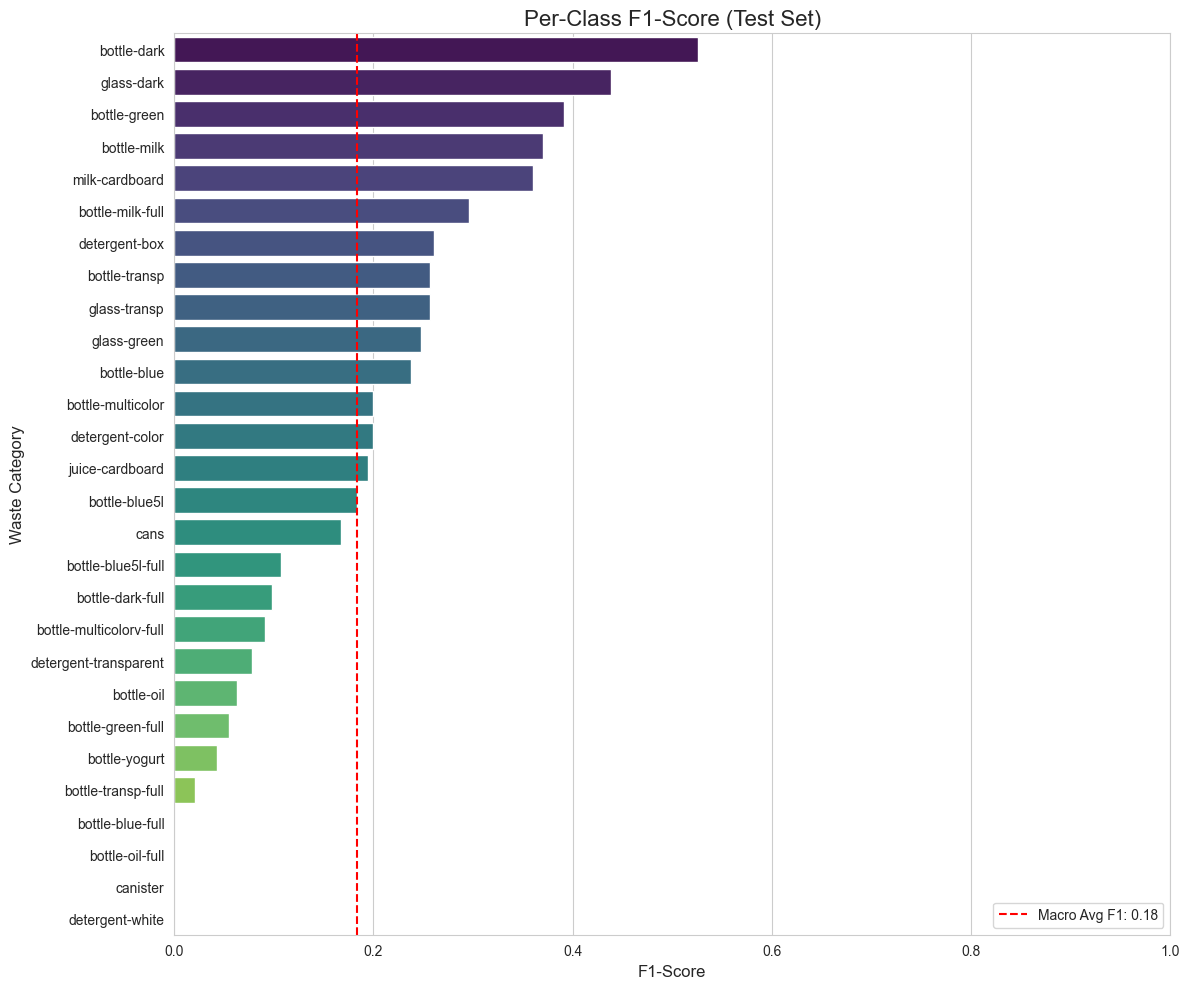

Plotting top misclassifications...


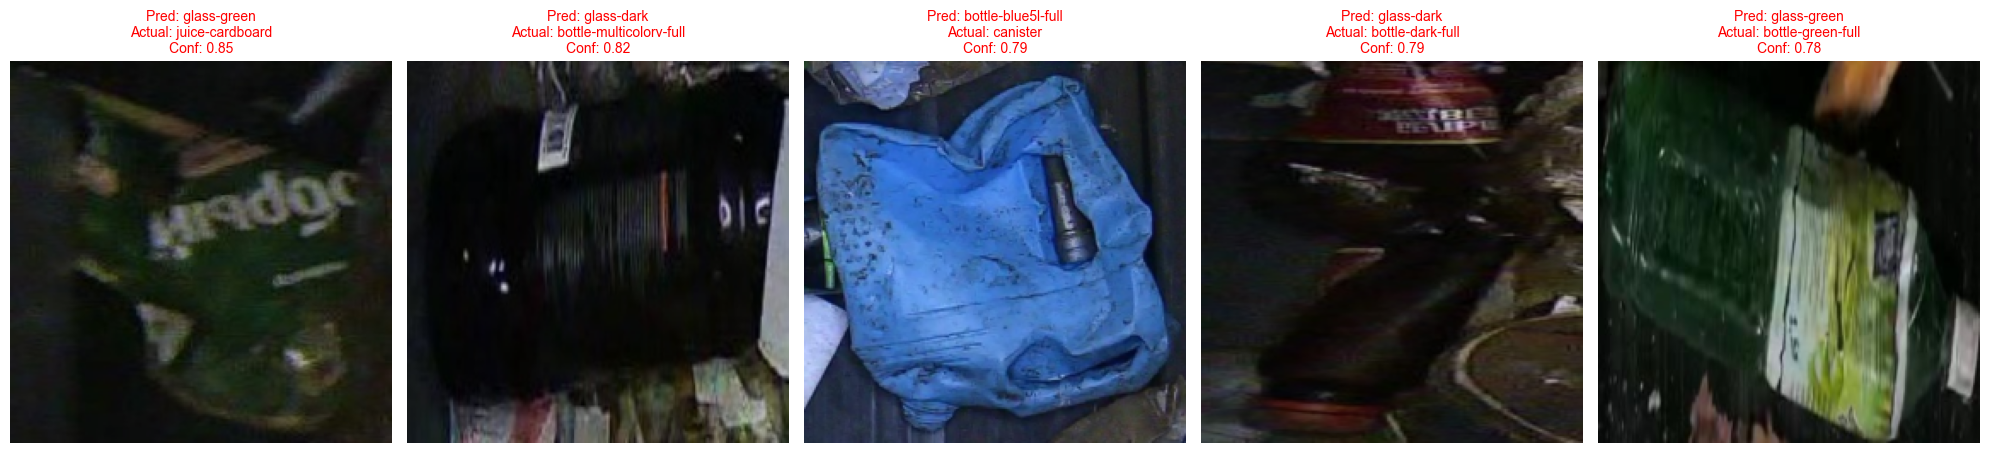

[Plot] Confusion matrix saved to experiments/results/resnet50/smoke_test\confusion_matrix.png


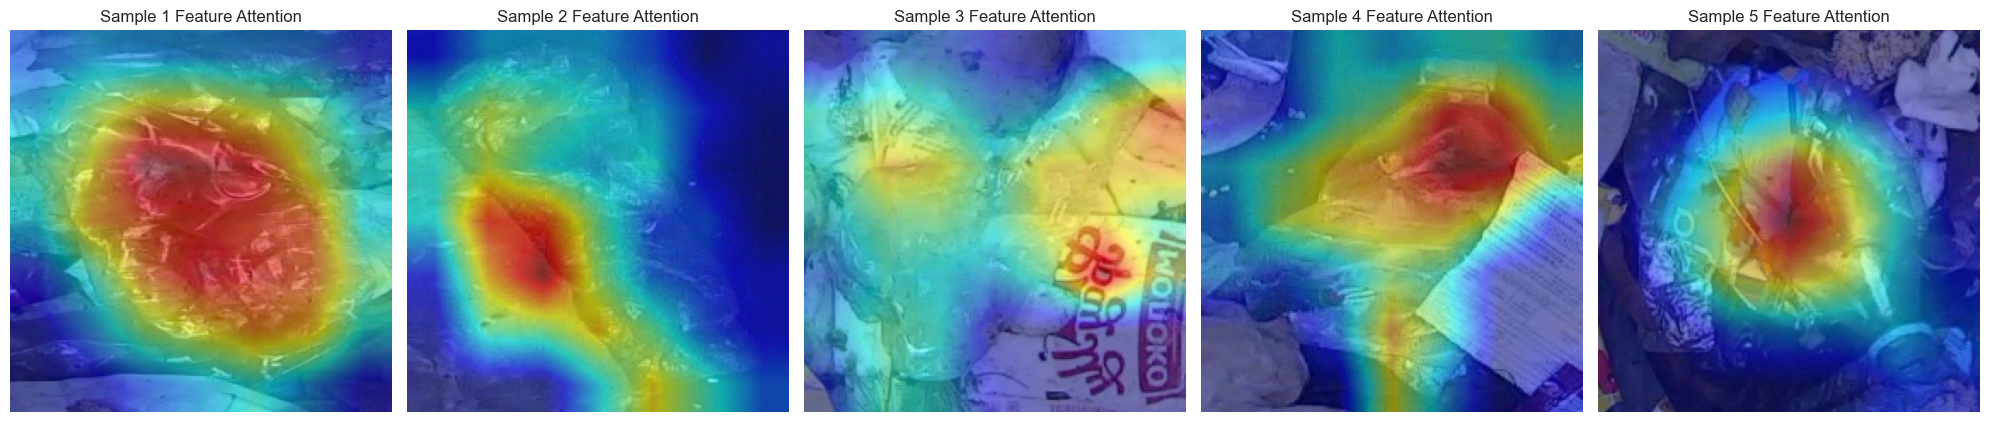

[Done] All test outputs saved to: experiments/results/resnet50/smoke_test


In [9]:
# Example: evaluate a run
run_evaluation("experiments/results/resnet50/smoke_test", True)